In [22]:
import pandas as pd

In [23]:
df=pd.read_csv('seattle-weather.csv')
df

,日期,降水量,最高气温,最低气温,风力,天气
0,2012/1/1,0.0,12.8,5.0,4.7,drizzle
1,2012/1/2,10.9,10.6,2.8,4.5,rain
2,2012/1/3,0.8,11.7,7.2,2.3,rain
3,2012/1/4,20.3,12.2,5.6,4.7,rain
4,2012/1/5,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...,...
1456,2015/12/27,8.6,4.4,1.7,2.9,rain
1457,2015/12/28,1.5,5.0,1.7,1.3,rain
1458,2015/12/29,0.0,7.2,0.6,2.6,fog
1459,2015/12/30,0.0,5.6,-1.0,3.4,sun


In [24]:
date=pd.to_datetime(df['日期'])
df['年']=date.dt.year
df['月']=date.dt.month
df['日']=date.dt.day
df

,日期,降水量,最高气温,最低气温,风力,天气,年,月,日
0,2012/1/1,0.0,12.8,5.0,4.7,drizzle,2012,1,1
1,2012/1/2,10.9,10.6,2.8,4.5,rain,2012,1,2
2,2012/1/3,0.8,11.7,7.2,2.3,rain,2012,1,3
3,2012/1/4,20.3,12.2,5.6,4.7,rain,2012,1,4
4,2012/1/5,1.3,8.9,2.8,6.1,rain,2012,1,5
...,...,...,...,...,...,...,...,...,...
1456,2015/12/27,8.6,4.4,1.7,2.9,rain,2015,12,27
1457,2015/12/28,1.5,5.0,1.7,1.3,rain,2015,12,28
1458,2015/12/29,0.0,7.2,0.6,2.6,fog,2015,12,29
1459,2015/12/30,0.0,5.6,-1.0,3.4,sun,2015,12,30


In [25]:
from sklearn.preprocessing import LabelEncoder

In [26]:
label=LabelEncoder()
df['天气']=label.fit_transform(df['天气'])
df.drop(columns=['日期'],inplace=True)

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

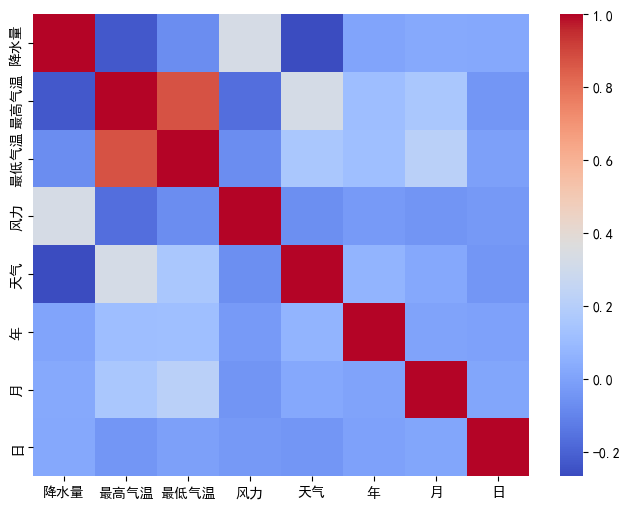

In [28]:
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),cmap='coolwarm')

In [30]:
x=df.drop(columns=['最低气温','天气'])
x

,降水量,最高气温,风力,年,月,日
0,0.0,12.8,4.7,2012,1,1
1,10.9,10.6,4.5,2012,1,2
2,0.8,11.7,2.3,2012,1,3
3,20.3,12.2,4.7,2012,1,4
4,1.3,8.9,6.1,2012,1,5
...,...,...,...,...,...,...
1456,8.6,4.4,2.9,2015,12,27
1457,1.5,5.0,1.3,2015,12,28
1458,0.0,7.2,2.6,2015,12,29
1459,0.0,5.6,3.4,2015,12,30


In [31]:
y=df['天气']
y

0       0
1       2
2       2
3       2
4       2
       ..
1456    2
1457    2
1458    1
1459    4
1460    4
Name: 天气, Length: 1461, dtype: int64

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [33]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [34]:
model=RandomForestClassifier(n_estimators=300)
model.fit(x_train,y_train)

RandomForestClassifier(n_estimators=300)

In [35]:
y_pred=model.predict(x_test)
accu=accuracy_score(y_test,y_pred)

In [36]:
accu

0.863481228668942

In [39]:
from sklearn.tree import plot_tree

Text(0.5, 1.0, '随机森林的一棵树')

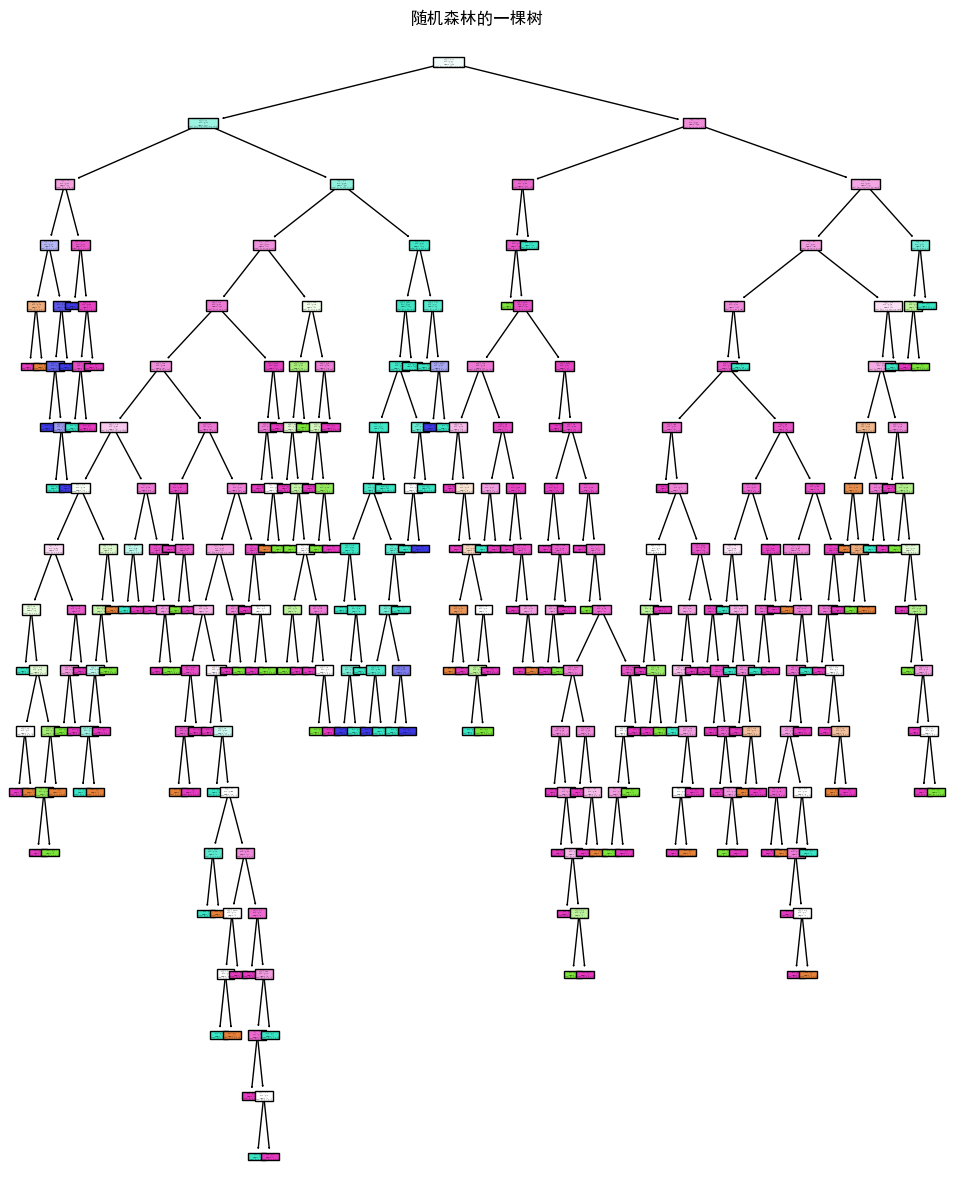

In [44]:
plt.figure(figsize=(12,15))
plot_tree(model.estimators_[0],filled=True)
plt.title('随机森林的一棵树')

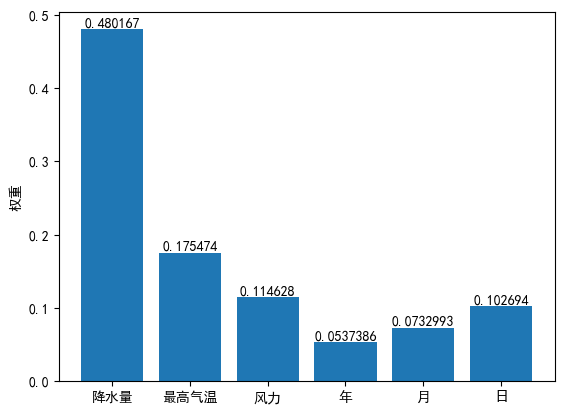

In [63]:
bar=plt.bar(x.columns,model.feature_importances_)
plt.ylabel('权重')
plt.bar_label(bar)
plt.show()